# Лабораторная работа №1

Вариант:
- Задача 4
- Задание 2

Выполнили студенты 25ИАД:
- Ерёменко Данил
- Кудасов Максим

## Формулировка задания

Для выполнения лабораторной работы рассмотрим функция из задачи 4:

$
f(x) = \cfrac{\rho}{2} \| Ax - b \|^2 + \sum_{i=1}^{m} \log\left(2 \cosh \bigl(u_i^\top (x-a) \bigr) \right),
$

где

- $x \in \mathbb{R}^n$ — переменная для оптимизации,
- $a \in \mathbb{R}^n$,
- $b \in \mathbb{R}^m$,
- $A \in \mathbb{R}^{m\times n}$,
- $u_i \in \mathbb{R}^n$,
- $\rho \ge 0$,
- $m = \frac{n}{5}$.

Для данной функции требуется выполнить несколько заданий. Среди них есть теоретическое и практическое.

## Теоретическая часть

Теоретические задания будут выполнены в текущем разделе. Список заданий следующий:
1. Проверить задачу на выпуклость
2. Выписать $\nabla f(x)$
3. Найти/оценить константы $L$ (Липшица градиента) и $\mu$ (сильной выпуклости)
4. Выписать условия оптимальности: $\nabla f(x^{+}) = 0$

### 1. Проверка задачи на выпуклость

По определению, $f(x)$ называется выпуклой, если для любых $x, y \in \mathbb{R}^n$ и любого $\lambda \in [0, 1]$ выполняется неравенство:
$$
f(\lambda x + (1 - \lambda) y) \le \lambda f(x) + (1 - \lambda) f(y)
$$

Из Семинара 2 (задача 3b) мы знаем, что сумма выпуклых функций также является выпуклой функцией. Поэтому для удобства разобьем нашу исходную функцию на две компоненты и докажем выпуклость каждой из них по определению:

1.  $f_1(x) = \cfrac{\rho}{2} \| Ax - b \|^2$
2.  $f_2(x) = \sum_{i=1}^m \log\left(2 \cosh \bigl(u_i^\top (x-a) \bigr) \right)$

#### 1. Доказательство выпуклости $f_1(x)$

##### Аффинное преобразование аргумента

Проверим сначала аффинное преобразование на предмет сохранения характера выпуклости. Для этого используем замену аргумента: $z = \lambda x + (1 - \lambda) y$.

Подставим её под норму:
$$
A(\lambda x + (1 - \lambda) y) - b = \lambda (Ax) + (1 - \lambda) (Ay) - \lambda b - (1 - \lambda) b
$$
$$
= \lambda (Ax - b) + (1 - \lambda) (Ay - b)
$$

Следовательно, аффинное преобразование под аргументом функции сохраняет характер выпуклости.

Перейдём далее к доказательству выпуклости нормы, возведения в квадрат и домножению на константу.

##### Выпуклость нормы

Исходя из того, что мы доказывали на семинаре 2 в задаче 9, мы знаем, что любая норма является выпуклой функцией:
$$
\| \lambda (Ax - b) + (1 - \lambda) (Ay - b) \| \le \lambda \| Ax - b \| + (1 - \lambda) \| Ay - b \|
$$

##### Выпуклость квадрата нормы

Для краткости обозначим $u = \| Ax - b \|$ и $v = \| Ay - b \|$.

Учитывая, что норма всегда неотрицательна ($u \ge 0$, $v \ge 0$), возведем обе части неравенства в квадрат:
$$
(\lambda u + (1 - \lambda) v)^2 \le (\lambda u)^2 + 2\lambda(1-\lambda)uv + ((1-\lambda)v)^2
$$

Далее вспомним, что $(u - v)^2 \ge 0$, откуда выводится, что $2uv \le u^2 + v^2$. Тогда:
$$
2\lambda(1-\lambda)uv \le \lambda(1-\lambda)(u^2 + v^2) = \lambda(1-\lambda)u^2 + \lambda(1-\lambda)v^2
$$

Так как у нас неравенство, то можем заменить $2\lambda (1-\lambda) uv$ на то, что больше его, сохранив тем самым знак неравенства (просто взяв сравнение с бОльшим числом):
$$
(\lambda u + (1 - \lambda) v)^2 \le \lambda^2 u^2 + \lambda(1-\lambda)u^2 + \lambda(1-\lambda)v^2 + (1-\lambda)^2 v^2
$$

Сгруппируем слагаемые:
$$
\lambda u^2 (\lambda + 1 - \lambda) + (1-\lambda) v^2 (\lambda + 1 - \lambda) = \lambda u^2 + (1 - \lambda) v^2
$$

То есть у нас выполняется неравенство:
$$
(\lambda u + (1 - \lambda) v)^2 \le \lambda u^2 + (1 - \lambda) v^2
$$

То есть возведение в квадрат сохраняет выпуклость.

##### Итоговое неравенство

$$
\| A(\lambda x + (1 - \lambda) y) - b \|^2 \le \lambda \| Ax - b \|^2 + (1 - \lambda) \| Ay - b \|^2
$$
Умножение на константу $\cfrac{\rho}{2} \ge 0$ не меняет знака неравенства (да и в задании 3(а) семинара 2 тоже это доказывали), следовательно, по определению функция $f_1(x)$ — выпуклая.

#### 2. Доказательство выпуклости $f_2(x)$

Так как сумма выпуклых функций выпукла (доказывали на семинаре), нам достаточно доказать выпуклость одного члена суммы (так как $u_i$ является фиксированным вектором). Рассмотрим функцию:
$$
h(x) = \log\left(2 \cosh \bigl(u_i^\top (x-a) \bigr) \right)
$$

По определению гиперболического косинуса $2 \cosh(z) = \exp(z) + \exp(-z)$. Отсюда преобразуем в более удобный набор функций:
$$
h(x) = \log\left( \exp\bigl(u_i^\top (x-a)\bigr) + \exp\bigl(-u_i^\top (x-a)\bigr) \right)
$$

Введём замену $x_\lambda = \lambda x + (1-\lambda)y$. Заметим, что аргумент экспоненты является аффинным преобразованием (и он сохраняет характер выпуклости):
$$
u_i^\top (x_\lambda - a) = \lambda u_i^\top (x - a) + (1-\lambda) u_i^\top (y - a)
$$

##### Замена аргумента

Для удобства введем скалярные обозначения: $z_x = u_i^\top (x - a)$ и $z_y = u_i^\top (y - a)$. 
Тогда нам нужно доказать неравенство:
$$
\log\left( \exp(\lambda z_x + (1-\lambda)z_y) + \exp(-\lambda z_x - (1-\lambda)z_y) \right)
$$
$$
\le \lambda \log\left(\exp(z_x) + \exp(-z_x)\right) + (1-\lambda) \log\left(\exp(z_y) + \exp(-z_y)\right)
$$

Внесем коэффициенты $\lambda$ и $(1-\lambda)$ под знак логарифма как степени:
$$
\lambda \log(A) + (1-\lambda) \log(B) = \log(A^\lambda B^{1-\lambda})
$$
Тогда правая часть примет вид:
$$
\log\left( \bigl(\exp(z_x) + \exp(-z_x)\bigr)^\lambda \cdot \bigl(\exp(z_y) + \exp(-z_y)\bigr)^{1-\lambda} \right)
$$

Так как логарифм — строго возрастающая функция, неравенство между логарифмами равносильно неравенству их аргументов. Нам остается доказать:
$$
\exp(\lambda z_x + (1-\lambda)z_y) + \exp(-\lambda z_x - (1-\lambda)z_y)
$$
$$
\le \bigl(\exp(z_x) + \exp(-z_x)\bigr)^\lambda \cdot \bigl(\exp(z_y) + \exp(-z_y)\bigr)^{1-\lambda}
$$

Разложим слагаемые в левой части, используя свойства степеней ($\exp(a+b) = \exp(a)\exp(b)$):
$$
(\exp(z_x))^\lambda (\exp(z_y))^{1-\lambda} + (\exp(-z_x))^\lambda (\exp(-z_y))^{1-\lambda}
$$

Теперь воспользуемся **неравенством Гёльдера** для сумм. В общем виде для векторов $p$ и $q$ и весов $\lambda \in [0, 1]$ оно гласит: $p_1^\lambda q_1^{1-\lambda} + p_2^\lambda q_2^{1-\lambda} \le (p_1 + p_2)^\lambda (q_1 + q_2)^{1-\lambda}$.
Положим:
- $p_1 = \exp(z_x)$
- $p_2 = \exp(-z_x)$
- $q_1 = \exp(z_y)$
- $q_2 = \exp(-z_y)$

Подставив эти значения в неравенство Гёльдера, мы в точности получаем требуемое неравенство:
$$
(\exp(z_x))^\lambda (\exp(z_y))^{1-\lambda} + (\exp(-z_x))^\lambda (\exp(-z_y))^{1-\lambda} \le \bigl(\exp(z_x) + \exp(-z_x)\bigr)^\lambda \cdot \bigl(\exp(z_y) + \exp(-z_y)\bigr)^{1-\lambda}
$$

Беря от обеих частей логарифм, мы возвращаемся к определению выпуклости для $h(x)$. Следовательно, каждый член суммы $h_i(x)$ выпукл, а значит, и вся сумма $f_2(x)$ **выпукла**.

#### Итоговая функция f(x)

Поскольку $f_1(x)$ и $f_2(x)$ являются выпуклыми функциями, их сумма $f(x) = f_1(x) + f_2(x)$ также является выпуклой функцией (как мы это уже доказывали на семинаре).

---

### 2. Вычисление градиента функции

Далее по заданию нужно найти $\nabla f(x)$.

Так как градиент -- линейный оператор, то мы можем себе позволить разделить нашу функцию на две части: $f(x) = f_1(x) + f_2(x)$, где
- $f_1(x) = \cfrac{\rho}{2} \| Ax - b \|^2$
- $f_2(x) = \sum_{i=1}^{m} \log\left(2 \cosh \bigl(u_i^\top (x-a) \bigr) \right)$

#### Градиент $f_1(x)$

Перепишем норму через скалярное произведение: $f_1(x) = \cfrac{\rho}{2} (Ax - b)^\top (Ax - b)$.
Используя матричное дифференцирование, получаем:
$$
\nabla f_1(x) = \rho A^\top (Ax - b)
$$

#### Градиент $f_2(x)$

Рассмотрим один член суммы: $h_i(x) = \log\left(2 \cosh \bigl(u_i^\top (x-a) \bigr) \right)$.

Обозначим скаляр $z_i = u_i^\top (x-a)$. Тогда $\nabla_x z_i = u_i$.

По правилу дифференцирования сложной функции:
$$
\frac{d}{dz_i} \log(2 \cosh(z_i)) = \cfrac{1}{2 \cosh(z_i)} \cdot 2 \sinh(z_i) = \tanh(z_i)
$$

Тогда градиент $h_i(x)$ по цепному правилу:
$$
\nabla h_i(x) = \tanh(z_i) \cdot \nabla_x z_i = \tanh\bigl(u_i^\top (x-a)\bigr) u_i
$$

Градиент суммы равен сумме градиентов:
$$
\nabla f_2(x) = \sum_{i=1}^{m} \tanh\bigl(u_i^\top (x-a)\bigr) u_i
$$

#### Итоговый градиент

$$
\nabla f(x) = \rho A^\top (Ax - b) + \sum_{i=1}^{m} \tanh\bigl(u_i^\top (x-a)\bigr) u_i
$$

---

### 3. Нахождение/оценка $L$ и $\mu$

Для оценки этих констант нам понадобится гессиан $\nabla^2 f(x)$. 
Мы знаем, что если для любого $x$ выполнено условие $\mu I \preceq \nabla^2 f(x) \preceq L I$, то $\mu$ — константа сильной выпуклости, а $L$ — константа Липшица градиента.

Найдем гессиан, продифференцировав градиент еще раз:
$$
\nabla^2 f(x) = \rho A^\top A + \sum_{i=1}^{m} \cfrac{1}{\cosh^2\bigl(u_i^\top (x-a)\bigr)} u_i u_i^\top
$$

#### Оценка константы $L$
Нам нужно найти оценку сверху для максимального собственного значения гессиана.
Заметим, что для любого $z \in \mathbb{R}$ выполняется $\cfrac{1}{\cosh^2(z)} \le 1$. Следовательно:
$$
\nabla^2 f(x) \preceq \rho A^\top A + \sum_{i=1}^{m} 1 \cdot u_i u_i^\top
$$
Обозначим через $U \in \mathbb{R}^{n \times m}$ матрицу, столбцами которой являются векторы $u_i$. Тогда $\sum_{i=1}^m u_i u_i^\top = U U^\top$.
Таким образом, константу $L$ можно оценить как максимальное собственное значение этой суммы:
$$
L = \lambda_{\max} \left( \rho A^\top A + U U^\top \right)
$$

#### Оценка константы $\mu$
Нам нужно найти оценку снизу для минимального собственного значения гессиана $\lambda_{\min}(\nabla^2 f(x))$.
Заметим, что $\cfrac{1}{\cosh^2(z)} > 0$, но эта дробь может быть сколь угодно близка к нулю при $z \to \pm\infty$. Поэтому второй член суммы может дать нулевой вклад в минимальное собственное значение.

Рассмотрим внимательно размерности задачи. Из условия известно, что:
- $A \in \mathbb{R}^{m \times n}$
- Векторы $u_i \in \mathbb{R}^n$, их количество равно $m$.
- $m = \frac{n}{5}$, то есть $m < n$.

Матрица $A^\top A$ имеет размер $n \times n$, но её ранг равен максимум $m = n/5$. Следовательно, у неё есть как минимум $n - m = 4n/5$ нулевых собственных значений. То же самое касается и матрицы $U U^\top$ — её ранг не превышает $m$.
Сумма этих двух матриц $\rho A^\top A + U U^\top$ будет иметь ранг не более $m + m = 2m = \frac{2n}{5}$.

Так как $\frac{2n}{5} < n$, итоговый гессиан вырожден для любого $x$. Его ядро нетривиально, а значит, его минимальное собственное значение всегда равно нулю:
$$
\lambda_{\min}(\nabla^2 f(x)) = 0
$$
Отсюда можно сделать вывод, что функция является выпуклой, но не является сильно выпуклой.

### 4. Условия оптимальности

Так как задача оптимизации является задачей минимизации, а сама функция $f(x)$ выпукла и дифференцируема, то необходимое и достаточное условие экстремума (минимума) первого порядка — это равенство градиента нулю.

Пусть $x^*$ — точка оптимума. Тогда условие $\nabla f(x^*) = 0$ записывается в виде:

$$
\rho A^\top (Ax^* - b) + \sum_{i=1}^{m} \tanh\bigl(u_i^\top (x^*-a)\bigr) u_i = 0
$$

## Практическая часть

Список заданий для выполнения практической части следующий:

1. Для каждого $n \in \{10, 20, \dots, 100\}$ сгенерировать 100 тестовых примеров и найти $x^*$ с помощью CVXPY (или любого другого сольвера). Проверить условие оптимальности.

2. Для каждого $n \in \{10, 20, \dots, 100\}$ и каждого тестового примера сгенерировать 100 начальных точек. Для точности $\varepsilon = 0.01$ реализовать методы:
   1.  Градиентный спуск с постоянным шагом $\gamma = \frac{1}{L}$.
   2.  Градиентный спуск с постоянным шагом $\gamma = \frac{1}{2L}$.

3. В качестве результата работы методов:
   1. Построить график траектории одного из методов, при $n = 2$ (если есть $m$, то $m = 1$).
   2. Для каждого $n \in \{10, 20, \dots, 100\}$ подсчитать среднее время работы метода и среднее число итераций (усреднение по всем начальным точкам и по всем тестовым примерам); сравнить с теоретическими оценками.
   3. Для одного тестового примера при $n = 10$ и нескольких различных начальных точек построить зависимость точности от числа итераций.
   4. Добавить регуляризацию Тихонова ($f_{\lambda}(x) = f(x) + \frac{\lambda}{2} \|x\|^2$) и повторить сравнение. Сравнить поведение методов при $\mu = 0$ с добавленной регуляризацией и при $\mu > 0$ без регуляризации. Как меняется сходимость метода при добавлении регуляризации при $\mu > 0$?
   5. Добавить адаптивный подбор шага и повторить сравнение.
   6. Для адаптивных методов сравнить глобальную константу $L$ со средним по траектории значением $\frac{1}{N} \sum_{k=1}^N L_k$; оценить среднее число итераций внутреннего цикла подбора шага.

4. Сравнить методы между собой и объяснить результаты. Какой метод сходится быстрее всего (для $\mu = 0$ и $\mu > 0$)?

In [13]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import time
import pandas as pd

Для дальнейшего удобства лучше заведём класс `Task`, т.к. его будет проще тащить по коду и не придётся визуально перегружать глаза кучей переменных.

In [ ]:
class Task:
    def __init__(self, n, m=None):
        self.n = n
        self.m = max(1, n // 5) if m is None else m
        self.A = np.random.randn(self.m, self.n)
        self.b = np.random.randn(self.m)
        self.a = np.random.randn(self.n)
        self.U = np.random.randn(self.n, self.m)
        self.rho = np.random.uniform(0.1, 1.0)

    def f(self, X, lam=0.0):
        b = self.b if X.ndim == 1 else self.b[:, None]
        a = self.a if X.ndim == 1 else self.a[:, None]

        norm_part = (self.rho / 2) * np.sum((self.A @ X - b)**2, axis=0)
        log_cosh = np.sum(np.logaddexp(self.U.T @ (X - a), -self.U.T @ (X - a)), axis=0)
        return norm_part + log_cosh + (lam / 2) * np.sum(X**2, axis=0)

    def grad(self, X, lam=0.0):
        b = self.b if X.ndim == 1 else self.b[:, None]
        a = self.a if X.ndim == 1 else self.a[:, None]

        g_norm = self.rho * self.A.T @ (self.A @ X - b)
        g_log = self.U @ np.tanh(self.U.T @ (X - a))
        return g_norm + g_log + lam * X

    def L(self):
        L_A = self.rho * np.linalg.norm(self.A.T @ self.A, ord=2)
        L_U = np.linalg.norm(self.U @ self.U.T, ord=2)
        return L_A + L_U

### Задание 1

Тут от нас требуется запустить готовый солвер для решения нашей задачи оптимизации, при том выявить зависимость от размерности в задаче.

In [34]:
# Наши параметры запуска
ns = np.arange(10, 110, 10)
num_tests = 100

In [35]:
results = []

for n in ns:
    grad_norms = []
    for _ in range(num_tests):
        t = Task(n)
        x_var = cp.Variable(n)

        term1 = (t.rho / 2) * cp.sum_squares(t.A @ x_var - t.b)
        term2 = sum(cp.log_sum_exp(cp.vstack([t.U[:, i] @ (x_var - t.a), -t.U[:, i] @ (x_var - t.a)])) for i in range(t.m))

        prob = cp.Problem(cp.Minimize(term1 + term2))
        prob.solve(solver=cp.SCS, warm_start=True)

        if x_var.value is not None:
            grad = t.grad(x_var.value)
            grad_norms.append(np.linalg.norm(grad))

    results.append({"Размерность (n)": n, "Средняя норма градиента в x*": np.mean(grad_norms)})

df_cvxpy = pd.DataFrame(results)
display(df_cvxpy)

,Размерность (n),Средняя норма градиента в x*
0,10,1.309536e-09
1,20,3.956562e-09
2,30,8.531489e-09
3,40,1.427495e-08
4,50,1.976704e-08
5,60,2.776432e-08
6,70,4.001393e-08
7,80,4.843378e-08
8,90,6.021011e-08
9,100,7.140568e-08


Так как средняя норма градиента находится в районе 0-я, то условие оптимальности выполнено.

### Задание 2 (кастомные методы)

Требуется реализовать градиентный спуск и запустить с 2-мя разными шагами (постоянными):
- $\gamma = \frac{1}{L}$ -- более агрессивный шаг
- $\gamma = \frac{1}{2L}$ -- более мягкий шаг 

Пункт 3.2 будет находиться здесь.

In [60]:
# Тут не обычный градиентный спуск, а который по всем точкам считает матрицы
# Сделали такой, т.к. иначе он считает по полчаса все точки
def gd(task, X0, gamma, lam=0.0, eps=1e-2, max_iter=5000, keep_hist=False):
    is_single = (X0.ndim == 1)
    X = X0.copy()
    if is_single:
        X = X.reshape(-1, 1)

    num_starts = X.shape[1]
    iters = np.zeros(num_starts, dtype=int)
    active = np.ones(num_starts, dtype=bool)

    hist_X = [X.copy()] if keep_hist else None
    hist_f = [task.f(X, lam)] if keep_hist else None

    for k in range(max_iter):
        if not np.any(active):
            break

        X_act = X[:, active]
        g = task.grad(X_act, lam)

        still_active = np.linalg.norm(g, axis=0) >= eps

        iters[active] += 1
        X[:, active] = X_act - gamma * g

        if keep_hist:
            hist_X.append(X.copy())
            hist_f.append(task.f(X, lam))

        active_idx = np.where(active)[0]
        active[active_idx[~still_active]] = False

    if is_single:
        if keep_hist:
            return X[:, 0], np.array(hist_X)[:, :, 0], np.array(hist_f)[:, 0], iters[0]
        return X[:, 0], iters[0]

    return (X, np.array(hist_X), np.array(hist_f), iters) if keep_hist else (X, iters)

In [40]:
# Параметры запуска
ns = np.arange(10, 110, 10)
num_examples = 100
num_starts = 100
eps = 1e-2

In [44]:
results = []
for n in ns:
    for _ in range(num_examples):
        t = Task(n)
        L = t.L()
        X0 = np.random.randn(n, num_starts)

        # Вызов для 1/L
        t0 = time.time()
        _, iters_L = gd(t, X0, gamma=1/L, eps=eps)
        results.append({"n": n, "Шаг": "1 / L", "Время(с)": time.time() - t0, "Итерации": np.mean(iters_L)})

        # Вызов для 1/2L
        t0 = time.time()
        _, iters_2L = gd(t, X0, gamma=1/(2*L), eps=eps)
        results.append({"n": n, "Шаг": "1 / 2L", "Время(с)": time.time() - t0, "Итерации": np.mean(iters_2L)})

df_summary = pd.DataFrame(results).groupby(["n", "Шаг"]).mean().reset_index()
display(df_summary.style.format({"Время(с)": "{:.5f}", "Итерации": "{:.1f}"}))

,n,Шаг,Время(с),Итерации
0,10,1 / 2L,0.00563,152.6
1,10,1 / L,0.00284,75.9
2,20,1 / 2L,0.01026,268.7
3,20,1 / L,0.00519,133.9
4,30,1 / 2L,0.01575,343.0
5,30,1 / L,0.00791,171.0
6,40,1 / 2L,0.01941,385.2
7,40,1 / L,0.00976,192.0
8,50,1 / 2L,0.02400,440.5
9,50,1 / L,0.01222,219.7


Отчётливо видно, что при шаге равном $\frac{1}{L}$ у нас сходимость примерно в два раза быстрее происходит, чем с более мягким шагом $\frac{1}{2L}$, что ожидаемо, т.к. мы с помощью константы Липшицева гарантируем, что функция будет расти не быстрее $L$, и соответственно для нахождения оптимума мы стараемся выбрать шаг, максимально близкий к нашей оценке, чтобы быстрее сходиться с гарантией нахождения оптимума.

### Задание 3

Здесь будет несколько подпунктов, их разобьём на отдельные разделы и для каждого приложим необходимый код.

#### Задание 3.1 (График траектории)

In [63]:
t = Task(n=2, m=1)
x0 = np.array([-3.0, 3.0])

In [64]:
_, hist_x, _, _ = gd(t, x0, gamma=1/t.L(), keep_hist=True)

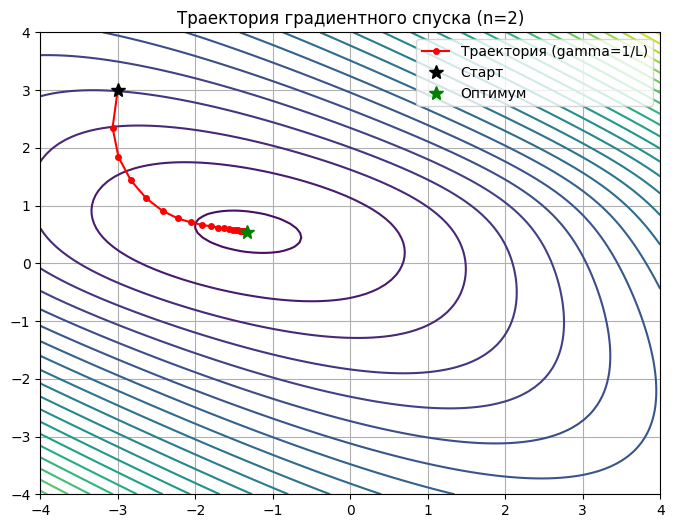

In [65]:
X, Y = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-4, 4, 100))
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = t.f(np.array([X[i, j], Y[i, j]]))

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=30, cmap='viridis')
plt.plot(hist_x[:, 0], hist_x[:, 1], 'ro-', markersize=4, label='Траектория (gamma=1/L)')
plt.plot(hist_x[0, 0], hist_x[0, 1], 'k*', markersize=10, label='Старт')
plt.plot(hist_x[-1, 0], hist_x[-1, 1], 'g*', markersize=10, label='Оптимум')
plt.legend()
plt.title('Траектория градиентного спуска (n=2)')
plt.grid(True)
plt.show()

#### Задание 3.3 (Точность от числа итераций)

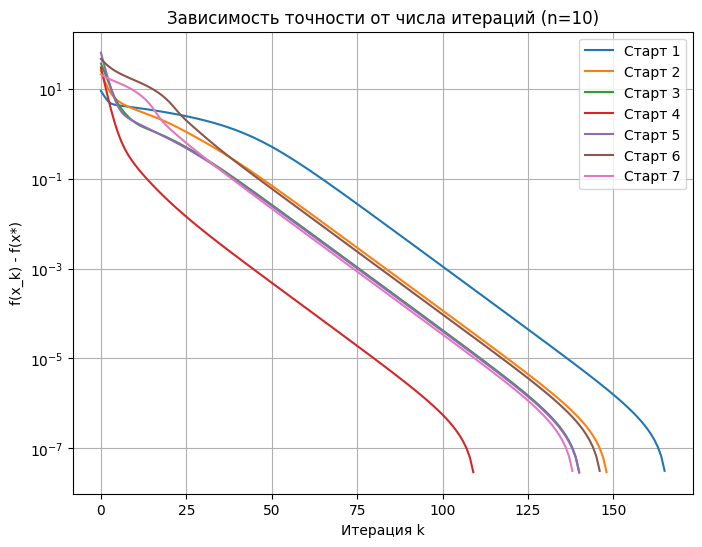

In [70]:
n = 10
starts = 7
t = Task(n=n)

plt.figure(figsize=(8, 6))
for i in range(starts):
    x0 = np.random.randn(n) * 2
    _, _, hist_f, _ = gd(t, x0, gamma=1/t.L(), eps=1e-3, keep_hist=True)
    accuracy = hist_f[:-1] - hist_f[-1] # f(x_k) - f(x*)
    plt.plot(accuracy, label=f'Старт {i+1}')

plt.yscale('log')
plt.xlabel('Итерация k')
plt.ylabel('f(x_k) - f(x*)')
plt.title(f'Зависимость точности от числа итераций (n={n})')
plt.legend()
plt.grid(True)
plt.show()

Как мы видим, с нашей оценкой $L$ мы почти всегда стабильно при повышении числа итераций повышеаем точность нашей модели, т.е. она с каждым шагом становится всё ближе к оптимуму, при том относительно стабильно.

#### Задание 3.4 (Влияние регуляризации)

Сначала разберёмся с тем, как мы можем, имея текущий пайплайн, применить регуляризацию.

При добавлении регуляризации Тихонова наша целевая функция принимает вид:
$$f_\lambda(x) = f(x) + \frac{\lambda}{2} \|x\|^2$$

Вычислим градиент этой функции:
$$\nabla f_\lambda(x) = \nabla f(x) + \lambda x$$

Константа Липшица градиента $L$ для дважды дифференцируемой функции определяется как максимальное собственное значение гессиана. Найдём его для новой функции:
$$\nabla^2 f_\lambda(x) = \nabla^2 f(x) + \lambda I,$$
где $I$ — единичная матрица.

Добавление слагаемого $\lambda I$ алгебраически означает сдвиг каждого собственного значения гессиана $\nabla^2 f(x)$ ровно на величину $\lambda$. 

Следовательно, максимальное собственное значение (константа Липшица $L$) и минимальное собственное значение (константа сильной выпуклости $\mu$) увеличиваются на $\lambda$:
* $L_{reg} = L + \lambda$
* $\mu_{reg} = \mu + \lambda$ (так как изначально $\mu=0$, теперь задача становится сильно выпуклой с $\mu_{reg} = \lambda$).

Поскольку теоретически обоснованный шаг для градиентного спуска обратно пропорционален константе Липшица ($\gamma = \frac{1}{L}$), для регуляризованной задачи необходимо использовать обновленный, чуть более короткий шаг $\gamma_{reg} = \frac{1}{L + \lambda}$. Если оставить старый шаг, он может оказаться слишком большим для новой функции, и метод потеряет гарантии сходимости.

In [108]:
# Заранее объявим его тут, хотя он должен находиться в пункте 3.5
def adaptive_gd(task, x0, L0, eps=1e-2, max_iter=5000):
    x = x0.copy()
    L_k = L0
    L_hist, inner_hist = [], []

    for k in range(max_iter):
        g = task.grad(x)
        if np.linalg.norm(g) < eps: break

        f_x = task.f(x)
        g_sq = np.sum(g**2)

        inner_loops = 0
        while True:
            inner_loops += 1
            x_next = x - (1 / L_k) * g
            if task.f(x_next) <= f_x - (1 / (2 * L_k)) * g_sq:
                break
            L_k *= 2

        x = x_next
        L_hist.append(L_k)
        inner_hist.append(inner_loops)
        L_k /= 2

    return x, L_hist, inner_hist, k + 1

In [127]:
n = 20
lam_reg = 0.5
t = Task(n=n)
X0 = np.random.randn(n, 100)

L_base = t.L()
L_reg = L_base + lam_reg

In [128]:
_, iters_no_reg = gd(t, X0, gamma=1/L_base, lam=0.0)
_, iters_reg = gd(t, X0, gamma=1/L_reg, lam=lam_reg)
# _, _, _, iters_no_reg = adaptive_gd(t, X0[1, :n], L0=L_base)
# _, _, _, iters_reg = adaptive_gd(t, X0[1, :n], L0=L_reg)

df_reg = pd.DataFrame({
    "Режим": ["Без регуляризации (mu = 0)", f"С регуляризацией (mu = {lam_reg})"],
    "Среднее число итераций": [np.mean(iters_no_reg), np.mean(iters_reg)]
})

display(df_reg.style.format({"Среднее число итераций": "{:.1f}"}))

,Режим,Среднее число итераций
0,Без регуляризации (mu = 0),69.1
1,С регуляризацией (mu = 0.5),516.8


Мы видим, что для нашей функции подобная регуляризация портит показатели значительно, примерно в 5 раз увеличивается число итераций. То есть в нашей задаче применять регуляризацию совершенно не стоит.

#### Задание 3.5-3.6 (Адаптивный подбор шага и сравнение)

In [129]:
n = 30
t = Task(n=n)
x0 = np.random.randn(n)

L_global = t.L()

_, it_const = gd(t, x0, gamma=1/L_global)
_, L_hist, inner_hist, it_adapt = adaptive_gd(t, x0, L0=L_global)

df_adapt = pd.DataFrame([
    {"Метрика": "Внешние итерации (Const шаг 1/L)", "Значение": it_const},
    {"Метрика": "Внешние итерации (Адаптивный шаг)", "Значение": it_adapt},
    {"Метрика": "Глобальная константа L", "Значение": L_global},
    {"Метрика": "Средняя локальная L_k по траектории", "Значение": np.mean(L_hist)},
    {"Метрика": "Среднее число внутренних циклов", "Значение": np.mean(inner_hist)}
])

display(df_adapt.style.format({"Значение": "{:.2f}"}))

,Метрика,Значение
0,Внешние итерации (Const шаг 1/L),123.00
1,Внешние итерации (Адаптивный шаг),41.00
2,Глобальная константа L,75.48
3,Средняя локальная L_k по траектории,29.96
4,Среднее число внутренних циклов,1.95


Мы отчётливо видим, что у нас адаптивный метод срабатывает сильно лучше, чем константный (примерно в 4 раза). К тому же, мы отчётливо видим, что средняя локальная $L_k$ у нас сильно меньше, чем глобально-выведенный $L$ для нашей функции, и, судя по всему, это одна из причин, почему алгоритм сходился быстрее:
- Он находил меньший $L$ (в обычном градиентном спуске мы худшую кривизну находим), чтобы по ней быстрее двигаться, а затем в нужный момент повысить её, чтобы не вылететь далеко от оптимума.
- Число внутренних циклов (подборов $L_k$) достаточно мало, в среднем всего 2 внутренних цикла. Это всё ещё хороший результат, так как если мы умножим внешнее число итераций на внутреннее, то у нас всё равно получится меньше шагов, чем вышло у градиентного спуска с константным шагом.

### Задание 4 (Выводы)

На основе проведённых практических экспериментов мы можем сделать следующие выводы:

**1. Проверка оптимальности и стабильность сходимости**
- Средняя норма градиента в найденных точках находится в районе нуля, условие сходимости выполняется. Как мы видим на графиках, с нашей оценкой $L$ точность стабильно повышается с ростом числа итераций — с каждым шагом мы всё ближе к оптимуму.

**2. Сравнение константных шагов ($\gamma = 1/L$ против $\gamma = 1/2L$)**
- Отчётливо видно, что при шаге, равном $\frac{1}{L}$, сходимость происходит примерно в два раза быстрее, чем с более "мягким" шагом $\frac{1}{2L}$. Это ожидаемо: константа Липшица гарантирует, что градиент функции будет меняться не быстрее $L$. Выбирая шаг, максимально близкий к нашей оценке (верхней границе), мы двигаемся к оптимуму максимально быстро, сохраняя при этом теоретическую гарантию сходимости.

**3. Влияние регуляризации Тихонова (переход от $\mu = 0$ к $\mu > 0$)**
- Мы видим, что для нашей функции подобная регуляризация значительно портит показатели — число итераций градиентного спуска увеличивается примерно в 5 раз. Из-за добавления $\lambda$ наш теоретический шаг уменьшается (становится $\frac{1}{L+\lambda}$), что в рамках нашей конкретной сгенерированной задачи приводит к замедлению. Следовательно, в данной задаче искусственно вводить сильную выпуклость не стоит.

**4. Эффективность адаптивного метода**
- Мы отчётливо видим, что адаптивный метод срабатывает сильно лучше, чем константный (сходится примерно в 4 раза быстрее по внешним итерациям). Основные причины его успеха:
  * **Локальная кривизна:** Средняя локальная $\hat{L}_k$ сильно меньше, чем глобально-выведенная $L$. Глобальная $L$ оценивает наихудшую кривизну функции, а адаптивный алгоритм находит меньший $L_k$ локально, что позволяет ему делать более длинные (смелые) шаги, повышая $L_k$ только в нужный момент, чтобы не "вылететь" из оптимума.
  * **Дешёвый поиск:** Число внутренних циклов (подборов $L_k$) достаточно мало — в среднем всего 2 итерации. Это отличный результат: если мы умножим внешнее число итераций на 2, у нас всё равно получится значительно меньше шагов (и вычислений функции), чем потребовалось градиентному спуску с константным шагом.

Итоговый выбор наилучшего алгоритма:
- **Для задачи без регуляризации ($\mu = 0$):**
  - Быстрее всего сходится адаптивный градиентный спуск, при том заметно
- **Для задачи с регуляризацией ($\mu > 0$):**
  - Для нашей задачи лучше не использовать регуляризацию вообще, она портит нам сходимость. Но даже так, адаптивный алгоритм всё равно оказался лучше (точнее, он не смог потерять в качестве)